# Lecture 3: Consumption

**Macroeconomics B -- Chapter 16**

By the end of this notebook you will be able to:
1. compute optimal consumption in the two-period model,
2. compare the MPC out of temporary and permanent income shocks,
3. show how borrowing constraints change current consumption,
4. illustrate precautionary saving numerically,
5. connect the model to real consumption and income data.


**Table of contents**<a id='toc0_'></a>
- 1. [The Keynesian Benchmark and the APC](#toc1_)
- 2. [Real Data: Consumption and Income](#toc2_)
  - 2.1. [FRED Data Setup](#toc2_1_)
- 3. [The Two-Period Model and the Closed-Form Solution](#toc3_)
- 4. [Temporary Versus Permanent Income](#toc4_)
- 5. [Borrowing Constraints and Precautionary Saving](#toc5_)
  - 5.1. [Borrowing Constraints](#toc5_1_)
  - 5.2. [Precautionary Saving](#toc5_2_)
- [Summary](#summary)


In [1]:
import io
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import requests

# Global plot settings
plt.rcParams.update({'axes.grid': True, 'grid.color': 'black',
                     'grid.alpha': 0.25, 'grid.linestyle': '--'})
plt.rcParams.update({'font.size': 14})

# Reproducibility
rng = np.random.default_rng(2025)


## 1. <a id='toc1_'></a>[The Keynesian Benchmark and the APC](#toc0_)

This section starts with the linear Keynesian consumption function,
$C_t = a + bY_t^d$. The benchmark is useful because it gives a constant
MPC and a declining APC as disposable income rises. That contrast helps
explain why cross-section data and long time-series evidence can point in
different directions.


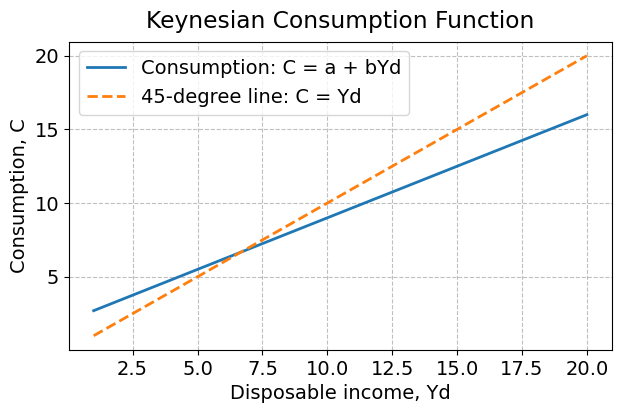

In [2]:
# -------------------------------------------------------
# Parameters
# -------------------------------------------------------
par = {'a': 2.0, 'b': 0.70}

Yd = np.linspace(1.0, 20.0, 400)
C = par['a'] + par['b'] * Yd
Y45 = Yd.copy()

fig = plt.figure(figsize=(7, 4))
ax = fig.add_subplot(1, 1, 1)

ax.plot(Yd, C, lw=2, label='Consumption: C = a + bYd')
ax.plot(Yd, Y45, lw=2, ls='--', label='45-degree line: C = Yd')

ax.set_title('Keynesian Consumption Function', pad=10)
ax.set_xlabel('Disposable income, Yd')
ax.set_ylabel('Consumption, C')
ax.legend(loc='upper left')
plt.show()


The slope of the consumption line is constant and equal to $b$. Because the consumption line is flatter than the 45-degree line, saving rises with disposable income.


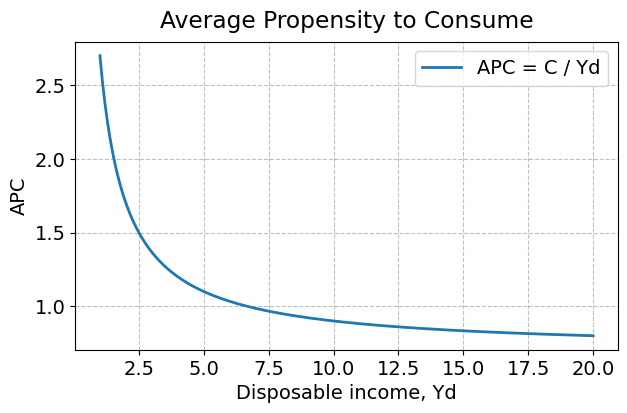

In [3]:
APC = C / Yd

fig = plt.figure(figsize=(7, 4))
ax = fig.add_subplot(1, 1, 1)

ax.plot(Yd, APC, lw=2, label='APC = C / Yd')

ax.set_title('Average Propensity to Consume', pad=10)
ax.set_xlabel('Disposable income, Yd')
ax.set_ylabel('APC')
ax.legend(loc='upper right')
plt.show()


The APC falls as income rises because the fixed term $a$ matters less at high income. This fits cross-section evidence better than the long-run time-series evidence discussed in the lecture.

For the exam, make sure you can explain why a constant MPC can coexist with a declining APC in the Keynesian benchmark.


**Task:** Change `a` and `b` and re-run the two figures.
How does a higher `a` change the APC curve, and how does a higher `b`
change the slope of the consumption function?


In [4]:
# write your code here

## 2. <a id='toc2_'></a>[Real Data: Consumption and Income](#toc0_)

This section uses official FRED data for real consumption and real
disposable income. The data build a simple APC proxy and show whether
consumption and income grow together over time.


### 2.1. <a id='toc2_1_'></a>[FRED Data Setup](#toc0_)

The code first tries to download official FRED observations. If the request
fails, it falls back to a small built-in dataset with annual January
observations. That keeps the notebook runnable from top to bottom.


In [5]:
# -------------------------------------------------------
# FRED data setup
# -------------------------------------------------------
FRED_API_KEY = '9fb7818ec505ebe0f36e58efc607471c'
FRED_BASE = 'https://api.stlouisfed.org/fred/series/observations'


def fetch_fred(series_id, api_key, frequency=None):
    """ Download a FRED series as a pandas Series with DatetimeIndex.

    Args:
        series_id (str): FRED series identifier.
        api_key   (str): FRED API key.
        frequency (str): optional aggregation choice.

    Returns:
        pd.Series with DatetimeIndex.
    """
    # a. build request
    params = {'series_id': series_id, 'api_key': api_key, 'file_type': 'json'}
    if frequency:
        params['frequency'] = frequency

    # b. fetch
    r = requests.get(FRED_BASE, params=params, timeout=10)
    r.raise_for_status()

    # c. parse
    obs = r.json()['observations']
    dates = pd.to_datetime([o['date'] for o in obs])
    values = pd.to_numeric([o['value'] for o in obs], errors='coerce')
    s = pd.Series(values, index=dates, name=series_id)
    print(f'Fetched {series_id}: {s.index[0].date()} to {s.index[-1].date()}, '
          f'{s.notna().sum()} non-null observations.')
    return s

try:
    pce = fetch_fred('PCEC96', FRED_API_KEY)
    dpi = fetch_fred('DSPIC96', FRED_API_KEY)

    data = pd.DataFrame({'consumption': pce, 'income': dpi}).dropna().copy()
    data = data[data.index.month == 1].copy()
    data = data[data.index.year >= 2007].copy()
    data = data.reset_index().rename(columns={'index': 'DATE'})

except Exception:
    pce_fallback = '''DATE,consumption
2007-01-01,11181.0
2008-01-01,11333.2
2009-01-01,11176.3
2010-01-01,11156.8
2011-01-01,11486.0
2012-01-01,11605.5
2013-01-01,11810.6
2014-01-01,11985.0
2015-01-01,12484.7
2016-01-01,12798.7
2017-01-01,13136.3
2018-01-01,13541.3
2019-01-01,13721.7
2020-01-01,14230.7
2021-01-01,14204.7
2022-01-01,15067.8
2023-01-01,15501.5
2024-01-01,15793.7
2025-01-01,16316.5
'''
    dpi_fallback = '''DATE,income
2007-01-01,11956.6
2008-01-01,12137.1
2009-01-01,12361.5
2010-01-01,12285.8
2011-01-01,12740.1
2012-01-01,12967.5
2013-01-01,12845.5
2014-01-01,13079.5
2015-01-01,13797.7
2016-01-01,14121.1
2017-01-01,14373.7
2018-01-01,14886.6
2019-01-01,15536.3
2020-01-01,15842.8
2021-01-01,18194.0
2022-01-01,16206.1
2023-01-01,16906.9
2024-01-01,17575.4
2025-01-01,17889.8
'''

    pce = pd.read_csv(io.StringIO(pce_fallback))
    dpi = pd.read_csv(io.StringIO(dpi_fallback))

    pce['DATE'] = pd.to_datetime(pce['DATE'])
    dpi['DATE'] = pd.to_datetime(dpi['DATE'])

    data = pce.merge(dpi, on='DATE', how='inner')
    data = data.reset_index(drop=True)

data['consumption_index'] = 100.0 * data['consumption'] / data['consumption'].iloc[0]
data['income_index'] = 100.0 * data['income'] / data['income'].iloc[0]
data['apc_proxy'] = data['consumption'] / data['income']

data.head()


Fetched PCEC96: 1959-01-01 to 2026-02-01, 230 non-null observations.
Fetched DSPIC96: 1959-01-01 to 2026-02-01, 806 non-null observations.


,DATE,consumption,income,consumption_index,income_index,apc_proxy
0,2007-01-01,11181.0,11956.6,100.000000,100.000000,0.935132
1,2008-01-01,11333.2,12137.1,101.361238,101.509626,0.933765
2,2009-01-01,11176.3,12361.5,99.957964,103.386414,0.904122
3,2010-01-01,11156.8,12285.8,99.783561,102.753291,0.908105
4,2011-01-01,11486.0,12740.1,102.727842,106.552866,0.901563


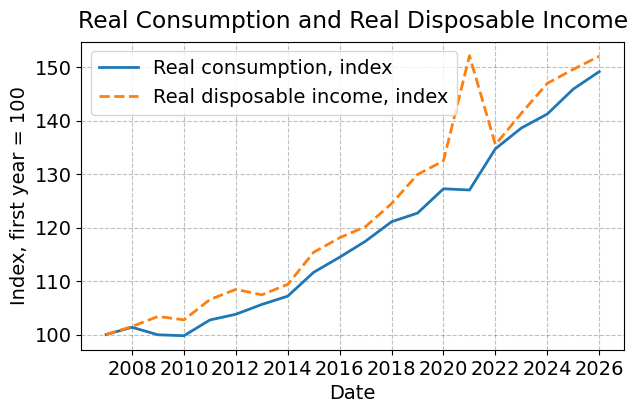

In [6]:
fig = plt.figure(figsize=(7, 4))
ax = fig.add_subplot(1, 1, 1)

ax.plot(data['DATE'], data['consumption_index'], lw=2, label='Real consumption, index')
ax.plot(data['DATE'], data['income_index'], lw=2, ls='--', label='Real disposable income, index')

ax.set_title('Real Consumption and Real Disposable Income', pad=10)
ax.set_xlabel('Date')
ax.set_ylabel('Index, first year = 100')
ax.legend(loc='upper left')
plt.show()


Real consumption and real disposable income move closely together over the sample. That pattern is hard to square with a simple model in which the APC must steadily decline as income grows.

For the exam, connect this long-run evidence to the move from the Keynesian consumption function to the PIH and life-cycle models.


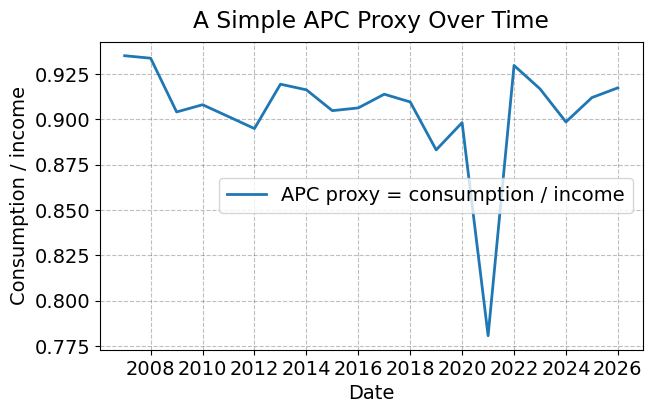

In [7]:
fig = plt.figure(figsize=(7, 4))
ax = fig.add_subplot(1, 1, 1)

ax.plot(data['DATE'], data['apc_proxy'], lw=2, label='APC proxy = consumption / income')

ax.set_title('A Simple APC Proxy Over Time', pad=10)
ax.set_xlabel('Date')
ax.set_ylabel('Consumption / income')
ax.legend(loc='best')
plt.show()


The APC proxy moves over time, but it does not show the strong downward trend predicted by the simple Keynesian benchmark. This is one reason economists use intertemporal consumption models with wealth and expected future income.


**Task:** Extend the section with the FRED
series `PSAVERT` and compare the APC proxy with the personal saving rate.
How do the two measures move together?


In [8]:
# write your code here

## 3. <a id='toc3_'></a>[The Two-Period Model and the Closed-Form Solution](#toc0_)

This section implements the two-period consumption model. The key object is
total wealth,
$W_1 = V_1 + Y_1^d + Y_2^d/(1+r)$.
With the utility function used in the lecture, the model implies

$$C_1 = \theta W_1, \qquad
\theta = \frac{1}{1 + (1+\phi)^{-\sigma}(1+r)^{\sigma-1}}.$$

The code below checks this result numerically by maximising lifetime
utility over a grid for $C_1$.


In [9]:
# -------------------------------------------------------
# Baseline parameters
# -------------------------------------------------------
par = {
    'V1': 2.0,
    'Y1d': 8.0,
    'Y2d': 10.0,
    'r': 0.03,
    'phi': 0.03,
    'sigma': 1.5
}

# Total wealth is current resources plus discounted future income.
W1 = par['V1'] + par['Y1d'] + par['Y2d'] / (1.0 + par['r'])

# The closed-form optimum comes from combining the Euler equation with
# the intertemporal budget constraint. The term theta is the share of
# total wealth consumed in period 1.
theta = 1.0 / (1.0 + (1.0 + par['phi'])**(-par['sigma']) * (1.0 + par['r'])**(par['sigma'] - 1.0))
C1_closed = theta * W1
C2_closed = (1.0 + par['r']) * (W1 - C1_closed)

# The grid search checks the formula without using the closed-form result.
# It tries many possible C1 values, computes the implied C2 from the budget
# constraint, and then evaluates lifetime utility at each candidate point.
C1_grid = np.linspace(0.1, W1 - 0.1, 2000)
C2_grid = (1.0 + par['r']) * (W1 - C1_grid)

power = (par['sigma'] - 1.0) / par['sigma']
U_grid = C1_grid**power / power + (1.0 / (1.0 + par['phi'])) * C2_grid**power / power

# The numerical optimum is the candidate C1 with the highest lifetime utility.
# If the algebra is right and the grid is fine enough, it should be very close
# to the closed-form optimum above.
i_star = np.argmax(U_grid)
C1_numeric = C1_grid[i_star]
C2_numeric = C2_grid[i_star]

results = pd.DataFrame({
    'Object': ['Total wealth W1', 'theta', 'Closed-form C1', 'Numeric C1', 'Closed-form C2', 'Numeric C2'],
    'Value': [W1, theta, C1_closed, C1_numeric, C2_closed, C2_numeric]
})

results


,Object,Value
0,Total wealth W1,19.708738
1,theta,0.507389
2,Closed-form C1,10.000000
3,Numeric C1,9.995878
4,Closed-form C2,10.000000
5,Numeric C2,10.004246


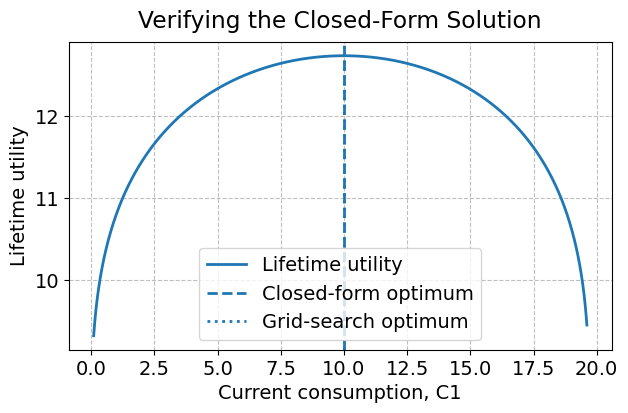

In [10]:
fig = plt.figure(figsize=(7, 4))
ax = fig.add_subplot(1, 1, 1)

ax.plot(C1_grid, U_grid, lw=2, label='Lifetime utility')
ax.axvline(C1_closed, lw=2, ls='--', label='Closed-form optimum')
ax.axvline(C1_numeric, lw=2, ls=':', label='Grid-search optimum')

ax.set_title('Verifying the Closed-Form Solution', pad=10)
ax.set_xlabel('Current consumption, C1')
ax.set_ylabel('Lifetime utility')
ax.legend(loc='best')

plt.show()


The two vertical lines almost coincide, so the algebraic solution matches the numerical optimum. The household chooses $C_1$ by balancing current utility against future utility.

For the exam, make sure you can verify a closed-form result numerically and explain why the optimum is interior in the unconstrained model.


**Task:** Change `phi`, `r`, or `sigma` and re-run the section.
Which parameter changes `theta` the most in your experiment, and what
does that imply for current consumption?


In [11]:
# write your code here

## 4. <a id='toc4_'></a>[Temporary Versus Permanent Income](#toc0_)

This section illustrates a core implication of the PIH. A one-off income
change only moves current consumption a little because the gain is spread
over many periods. A permanent change in income moves current consumption
much more because wealth rises by much more.


In [12]:
# -------------------------------------------------------
# Parameters
# -------------------------------------------------------
par = {
    'N': 20,
    'r': 0.03
}

theta_N = (par['r'] / (1.0 + par['r'])) / (1.0 - (1.0 + par['r'])**(-par['N']))

periods = np.arange(par['N'])
temp_response = np.empty(par['N'])
perm_response = np.empty(par['N'])

for t in range(par['N']):
    temp_response[t] = theta_N
    perm_response[t] = 1.0

mpc_table = pd.DataFrame({
    'Shock type': ['Temporary shock today', 'Permanent shock in every remaining period'],
    'Current MPC': [theta_N, 1.0]
})

mpc_table


,Shock type,Current MPC
0,Temporary shock today,0.065258
1,Permanent shock in every remaining period,1.000000


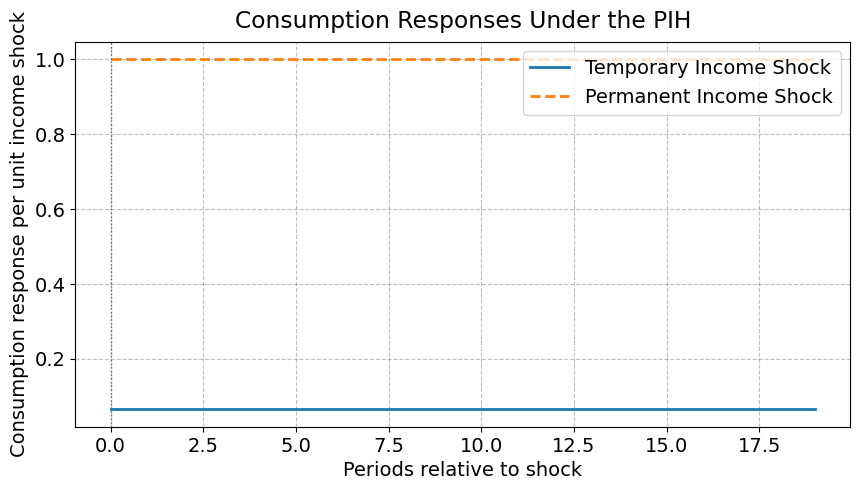

In [13]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1)

ax.plot(periods, temp_response, lw=2, label='Temporary Income Shock')
ax.plot(periods, perm_response, lw=2, ls='--', label='Permanent Income Shock')

ax.axvline(0, lw=1, ls=':')

ax.annotate(
    'Shock Arrives',
    xy=(0, 0.0),
    xytext=(0.6, 0.18),
    arrowprops=dict(arrowstyle='->', lw=1),
    ha='left',
    va='center'
)

ax.set_title('Consumption Responses Under the PIH', pad=10)
ax.set_xlabel('Periods relative to shock')
ax.set_ylabel('Consumption response per unit income shock')
ax.legend(loc='upper right')

plt.show()

A temporary shock produces a small and smooth rise in consumption each period. A permanent shock has a much larger current MPC because lifetime wealth rises much more.


**Task:** Change the horizon `N` and the interest rate `r`.
Does the temporary MPC become larger or smaller when the household has
fewer periods left to smooth over?


In [14]:
# write your code here

## 5. <a id='toc5_'></a>[Borrowing Constraints and Precautionary Saving](#toc0_)

The unconstrained Euler equation is not the whole story. If households
cannot borrow freely, current consumption can be capped by current
resources. If future income is risky, households may also save more today,
even when expected future income is unchanged.


### 5.1. <a id='toc5_1_'></a>[Borrowing Constraints](#toc0_)

This section compares an unconstrained household with a constrained
household. The constrained household must satisfy $A_1 \geq 0$, so current
consumption cannot exceed current resources, $V_1 + Y_1^d$.


In [15]:
# -------------------------------------------------------
# Parameters
# -------------------------------------------------------
par = {
    'V1': 0.0,
    'Y1d': 4.0,
    'r': 0.02,
    'phi': 0.02,
    'sigma': 1.5
}

resources_today = par['V1'] + par['Y1d']
theta = 1.0 / (1.0 + (1.0 + par['phi'])**(-par['sigma']) * (1.0 + par['r'])**(par['sigma'] - 1.0))

Y2_grid = np.linspace(0.0, 12.0, 400)
C1_uncon = np.empty(Y2_grid.size)
C1_con = np.empty(Y2_grid.size)

for i in range(Y2_grid.size):
    W1 = resources_today + Y2_grid[i] / (1.0 + par['r'])
    C1_uncon[i] = theta * W1
    C1_con[i] = min(C1_uncon[i], resources_today)

kink_index = np.argmax(C1_uncon >= resources_today)
Y2_kink = Y2_grid[kink_index]


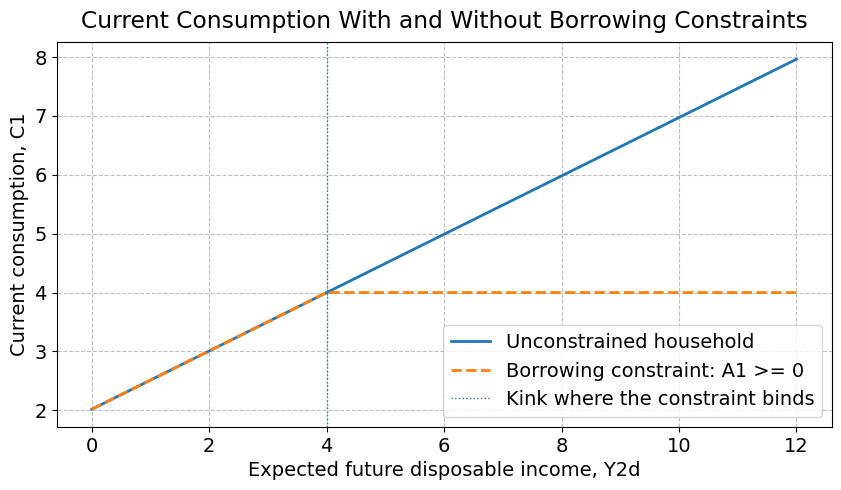

In [16]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1)

ax.plot(Y2_grid, C1_uncon, lw=2, label='Unconstrained household')
ax.plot(Y2_grid, C1_con, lw=2, ls='--', label='Borrowing constraint: A1 >= 0')
ax.axvline(Y2_kink, lw=1, ls=':', label='Kink where the constraint binds')

ax.set_title('Current Consumption With and Without Borrowing Constraints', pad=10)
ax.set_xlabel('Expected future disposable income, Y2d')
ax.set_ylabel('Current consumption, C1')
ax.legend(loc='lower right')

plt.show()


Once the unconstrained choice would require borrowing, the constrained household is stuck at current resources. The vertical line marks the point where the Euler equation stops determining current consumption by itself.

For the exam, make sure you can explain why constrained households can have a higher MPC out of current income.


**Task:** Change `Y1d` or `V1` and re-run the section.
Does the kink move left or right when current resources increase?


In [17]:
# write your code here

### 5.2. <a id='toc5_2_'></a>[Precautionary Saving](#toc0_)

This section keeps expected future income fixed and increases its risk.
The household chooses end-of-period assets from a grid, and the output
tracks optimal current consumption. With prudence, more risk should reduce
current consumption and raise saving.


In [18]:
# -------------------------------------------------------
# Parameters
# -------------------------------------------------------
par = {
    'resources_today': 6.0,
    'Ybar2': 5.0,
    'r': 0.02,
    'phi': 0.02,
    'sigma': 2.0
}

A1_grid = np.linspace(0.0, par['resources_today'] - 0.01, 1200)
risk_grid = np.linspace(0.0, 3.0, 61)

C1_star = np.empty(risk_grid.size)
A1_star = np.empty(risk_grid.size)

power = (par['sigma'] - 1.0) / par['sigma']

for i in range(risk_grid.size):
    spread = risk_grid[i]
    Y2_low = par['Ybar2'] - spread
    Y2_high = par['Ybar2'] + spread

    EU = np.empty(A1_grid.size)

    for j in range(A1_grid.size):
        A1 = A1_grid[j]
        C1 = par['resources_today'] - A1
        C2_low = (1.0 + par['r']) * A1 + Y2_low
        C2_high = (1.0 + par['r']) * A1 + Y2_high

        u1 = C1**power / power
        u2_low = C2_low**power / power
        u2_high = C2_high**power / power

        EU[j] = u1 + (1.0 / (1.0 + par['phi'])) * 0.5 * (u2_low + u2_high)

    j_star = np.argmax(EU)
    A1_star[i] = A1_grid[j_star]
    C1_star[i] = par['resources_today'] - A1_star[i]


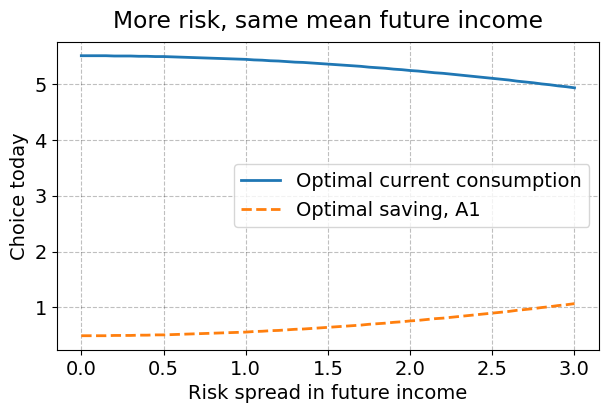

In [19]:
fig = plt.figure(figsize=(7, 4))
ax = fig.add_subplot(1, 1, 1)

ax.plot(risk_grid, C1_star, lw=2, label='Optimal current consumption')
ax.plot(risk_grid, A1_star, lw=2, ls='--', label='Optimal saving, A1')

ax.set_title('More risk, same mean future income', pad=10)
ax.set_xlabel('Risk spread in future income')
ax.set_ylabel('Choice today')
ax.legend(loc='best')

plt.show()


As risk rises, optimal current consumption falls and saving rises. The mechanism is not lower expected income because the mean of future income is fixed in every experiment.


**Task:** Lower `sigma` and re-run the section.
Does the precautionary-saving effect become stronger or weaker in your experiment?


In [20]:
# write your code here

## <a id='summary'></a>Summary

| Equation | Meaning |
|---|---|
| $C_t = a + bY_t^d$ | Keynesian benchmark with constant MPC |
| $C_1 = \theta\left(V_1 + Y_1^d + \frac{Y_2^d}{1+r}\right)$ | Current consumption depends on wealth and future income |
| $\theta = \frac{1}{1 + (1+\phi)^{-\sigma}(1+r)^{\sigma-1}}$ | Share of total wealth consumed today |
| $\text{MPC}_{\text{temp}} = \theta_N < 1$ and $\text{MPC}_{\text{perm}} = 1$ | Temporary income is spread out, permanent income is not |
| $u'(C_1) = \mu_1 + \frac{1+r}{1+\phi}u'(C_2)$ | Borrowing constraints add a wedge to the Euler equation |

**Socrative room:** MACROECONOMICSB
